# Insurance Claim Fraud Detection — Model 4: Ensemble (Meta-Learner) + Decision Fusion

This notebook combines the three "perspectives" from the project abstract:
- **Random Forest** (supervised)
- **XGBoost** (supervised) — falls back to `HistGradientBoostingClassifier` here only because
  this sandbox has no internet access to `pip install xgboost` (see the note in the XGBoost
  notebook; swap back automatically once xgboost is installed).
- **Isolation Forest** (unsupervised anomaly detection)

into a single **stacked meta-learner** (Logistic Regression), and adds a simple
**decision-fusion layer** that labels each test claim as *high-confidence fraud*,
*high-confidence legit*, or **flagged for human review** when the signals disagree — exactly the
three-way outcome described in the project abstract.

This notebook is fully self-contained: it repeats cleaning/encoding and (re)trains all three
base models itself, so it can be run on its own without needing the other three notebooks to
have been run first.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print("xgboost is installed - using the real XGBClassifier as the boosting base learner.")
except ImportError:
    from sklearn.ensemble import HistGradientBoostingClassifier as XGBClassifier
    XGB_AVAILABLE = False
    print("xgboost is NOT installed here - using HistGradientBoostingClassifier as a drop-in "
          "stand-in for the boosting base learner (see the XGBoost notebook for details).")


xgboost is installed - using the real XGBClassifier as the boosting base learner.


## 1. Load, check fraud ratio, clean (identical to the other 3 notebooks)

In [16]:
df = pd.read_csv("fraud_oracle.csv")
print("Shape:", df.shape)
pct = df['FraudFound_P'].value_counts(normalize=True) * 100
print("Class percentage:\n", pct.round(2))

df.loc[(df['Age'] == 0) & (df['AgeOfPolicyHolder'] == '16 to 17'), 'Age'] = 17
df.loc[df['DayOfWeekClaimed'] == '0', 'DayOfWeekClaimed'] = 'Monday'
df.loc[df['MonthClaimed'] == '0', 'MonthClaimed'] = 'Jul'
df = df.drop(columns=['PolicyNumber'], errors='ignore')


Shape: (15420, 33)
Class percentage:
 FraudFound_P
0    94.01
1     5.99
Name: proportion, dtype: float64


In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['FraudFound_P'])
y = df['FraudFound_P']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("X_train:", X_train.shape, " X_test:", X_test.shape)


X_train: (12336, 31)  X_test: (3084, 31)


## 2. Feature encoding (identical to the other 3 notebooks)

In [18]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = ['WeekOfMonth','WeekOfMonthClaimed','Age','RepNumber','Deductible','DriverRating','Year']

ordinal_maps = {
    'Days_Policy_Accident': ['none','1 to 7','8 to 15','15 to 30','more than 30'],
    'Days_Policy_Claim':    ['none','8 to 15','15 to 30','more than 30'],
    'PastNumberOfClaims':   ['none','1','2 to 4','more than 4'],
    'AgeOfVehicle':         ['new','2 years','3 years','4 years','5 years','6 years','7 years','more than 7'],
    'AgeOfPolicyHolder':    ['16 to 17','18 to 20','21 to 25','26 to 30','31 to 35','36 to 40','41 to 50','51 to 65','over 65'],
    'NumberOfSuppliments':  ['none','1 to 2','3 to 5','more than 5'],
    'AddressChange_Claim':  ['no change','under 6 months','1 year','2 to 3 years','4 to 8 years'],
    'NumberOfCars':         ['1 vehicle','2 vehicles','3 to 4','5 to 8','more than 8'],
    'VehiclePrice':         ['less than 20000','20000 to 29000','30000 to 39000','40000 to 59000','60000 to 69000','more than 69000'],
}
ordinal_cols = list(ordinal_maps.keys())

categorical_cols = ['Month','DayOfWeek','Make','AccidentArea','DayOfWeekClaimed','MonthClaimed',
                    'Sex','MaritalStatus','Fault','PolicyType','VehicleCategory',
                    'PoliceReportFiled','WitnessPresent','AgentType','BasePolicy']

def ordinal_encode(data):
    data = data.copy()
    for col, order in ordinal_maps.items():
        data[col] = data[col].map({v: i for i, v in enumerate(order)})
    return data

X_train_ord = ordinal_encode(X_train)
X_test_ord  = ordinal_encode(X_test)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train_ord[categorical_cols])
ohe_cols = ohe.get_feature_names_out(categorical_cols)
ohe_train = pd.DataFrame(ohe.transform(X_train_ord[categorical_cols]), columns=ohe_cols, index=X_train_ord.index)
ohe_test  = pd.DataFrame(ohe.transform(X_test_ord[categorical_cols]),  columns=ohe_cols, index=X_test_ord.index)

scaler = StandardScaler()
scaler.fit(X_train_ord[numeric_cols])
num_train = pd.DataFrame(scaler.transform(X_train_ord[numeric_cols]), columns=numeric_cols, index=X_train_ord.index)
num_test  = pd.DataFrame(scaler.transform(X_test_ord[numeric_cols]),  columns=numeric_cols, index=X_test_ord.index)

X_train_final = pd.concat([num_train, X_train_ord[ordinal_cols], ohe_train], axis=1)
X_test_final  = pd.concat([num_test,  X_test_ord[ordinal_cols],  ohe_test],  axis=1)

print("Final encoded shapes -> train:", X_train_final.shape, " test:", X_test_final.shape)


Final encoded shapes -> train: (12336, 104)  test: (3084, 104)


## 3. Base learners: light hyperparameter search

For stacking we need each base learner's **out-of-fold (OOF) predictions** on the training set
(so the meta-learner is never trained on predictions a model has already "seen" for that row —
otherwise the meta-learner would overfit to the base models' training performance). We first pick
reasonable hyperparameters with a quick `RandomizedSearchCV` (Stratified 3-fold, PR-AUC scoring),
then in the next section use those exact settings to generate OOF predictions with
`cross_val_predict` and a matching manual CV loop for Isolation Forest.

In [19]:
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              average_precision_score, classification_report, confusion_matrix)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# --- Random Forest ---
rf_param_dist = {'n_estimators': [150, 250], 'max_depth': [10, None], 'min_samples_leaf': [1, 2]}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1),
    rf_param_dist, n_iter=4, scoring='average_precision', cv=cv, random_state=RANDOM_STATE, n_jobs=1)
rf_search.fit(X_train_final, y_train)
best_rf = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)

# --- Boosting (XGBoost or HistGradientBoosting fallback) ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
if XGB_AVAILABLE:
    boost_param_dist = {'n_estimators': [150, 250], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
    boost_base = XGBClassifier(eval_metric='aucpr', random_state=RANDOM_STATE,
                                scale_pos_weight=scale_pos_weight, n_jobs=1)
else:
    boost_param_dist = {'max_iter': [150, 250], 'max_depth': [5, None], 'learning_rate': [0.05, 0.1]}
    boost_base = XGBClassifier(random_state=RANDOM_STATE, class_weight='balanced')

boost_search = RandomizedSearchCV(boost_base, boost_param_dist, n_iter=4,
                                   scoring='average_precision', cv=cv, random_state=RANDOM_STATE, n_jobs=1)
boost_search.fit(X_train_final, y_train)
best_boost = boost_search.best_estimator_
print("Best boosting params:", boost_search.best_params_)

# --- Isolation Forest contamination (anchored near the true fraud ratio) ---
if_contamination = float(y_train.mean())
if_n_estimators = 200
print(f"Isolation Forest -> n_estimators={if_n_estimators}, contamination={if_contamination:.4f}")


Best RF params: {'n_estimators': 250, 'min_samples_leaf': 2, 'max_depth': None}
Best boosting params: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.05}
Isolation Forest -> n_estimators=200, contamination=0.0598


## 4. Out-of-fold predictions -> stacked meta-features

`oof_rf` and `oof_boost` come from `cross_val_predict` (standard scikit-learn OOF machinery).
Isolation Forest isn't a classifier with `.fit(X, y)`, so its OOF loop is written manually: for
each fold it is fit on the training portion only (it never uses `y`) and scores the held-out
portion.

In [20]:
oof_rf = cross_val_predict(best_rf, X_train_final, y_train, cv=cv, method='predict_proba', n_jobs=1)[:, 1]
oof_boost = cross_val_predict(best_boost, X_train_final, y_train, cv=cv, method='predict_proba', n_jobs=1)[:, 1]

oof_if = np.zeros(len(X_train_final))
for tr_idx, val_idx in cv.split(X_train_final, y_train):
    iso_fold = IsolationForest(n_estimators=if_n_estimators, contamination=if_contamination,
                                random_state=RANDOM_STATE, n_jobs=1)
    iso_fold.fit(X_train_final.iloc[tr_idx])
    oof_if[val_idx] = -iso_fold.score_samples(X_train_final.iloc[val_idx])

print("OOF PR-AUC  (RF):      ", round(average_precision_score(y_train, oof_rf), 4))
print("OOF PR-AUC  (Boosting):", round(average_precision_score(y_train, oof_boost), 4))
print("OOF PR-AUC  (IF):      ", round(average_precision_score(y_train, oof_if), 4))

meta_X_train = np.column_stack([oof_rf, oof_boost, oof_if])
print("\nMeta-feature matrix for training the meta-learner:", meta_X_train.shape)


OOF PR-AUC  (RF):       0.2134
OOF PR-AUC  (Boosting): 0.2274
OOF PR-AUC  (IF):       0.0599

Meta-feature matrix for training the meta-learner: (12336, 3)


## 5. Train the meta-learner

**Logistic Regression** is used as the meta-learner: it's simple, well-calibrated, resistant to
overfitting on just 3 input features, and its coefficients directly show how much the
meta-learner trusts each base model — all useful properties for an interpretable "decision
support" system as described in the project abstract.

In [21]:
meta_learner = LogisticRegression(class_weight='balanced', max_iter=1000)
meta_learner.fit(meta_X_train, y_train)

coef_df = pd.DataFrame({
    'base_model': ['Random Forest', 'Boosting (XGBoost/HGB)', 'Isolation Forest'],
    'meta_coefficient': meta_learner.coef_[0]
}).sort_values('meta_coefficient', ascending=False)
print("Meta-learner coefficients (higher = more weight given to that base model's signal):")
print(coef_df.to_string(index=False))


Meta-learner coefficients (higher = more weight given to that base model's signal):
            base_model  meta_coefficient
Boosting (XGBoost/HGB)          4.607523
         Random Forest          1.791305
      Isolation Forest          0.858232


## 6. Refit base learners on the full training set, then predict on the test set

In [22]:
best_rf.fit(X_train_final, y_train)
best_boost.fit(X_train_final, y_train)

iso_final = IsolationForest(n_estimators=if_n_estimators, contamination=if_contamination,
                             random_state=RANDOM_STATE, n_jobs=1)
iso_final.fit(X_train_final)

rf_test_proba = best_rf.predict_proba(X_test_final)[:, 1]
boost_test_proba = best_boost.predict_proba(X_test_final)[:, 1]
if_test_score = -iso_final.score_samples(X_test_final)

meta_X_test = np.column_stack([rf_test_proba, boost_test_proba, if_test_score])
ensemble_test_proba = meta_learner.predict_proba(meta_X_test)[:, 1]
ensemble_test_pred = (ensemble_test_proba >= 0.5).astype(int)

print("Base learners refit and scored on the test set.")


Base learners refit and scored on the test set.


## 7. Model comparison: individual models vs the ensemble

In [23]:
def compute_metrics(y_true, proba, pred):
    return {
        'Precision': precision_score(y_true, pred),
        'Recall': recall_score(y_true, pred),
        'F1': f1_score(y_true, pred),
        'ROC-AUC': roc_auc_score(y_true, proba),
        'PR-AUC': average_precision_score(y_true, proba),
    }

if_test_norm = (if_test_score - if_test_score.min()) / (if_test_score.max() - if_test_score.min())
if_test_pred = (if_test_norm >= 0.5).astype(int)

comparison = pd.DataFrame({
    'Random Forest': compute_metrics(y_test, rf_test_proba, (rf_test_proba >= 0.5).astype(int)),
    'Boosting (XGB/HGB)': compute_metrics(y_test, boost_test_proba, (boost_test_proba >= 0.5).astype(int)),
    'Isolation Forest': compute_metrics(y_test, if_test_norm, if_test_pred),
    'Ensemble (meta-learner)': compute_metrics(y_test, ensemble_test_proba, ensemble_test_pred),
}).T

print("=== Model comparison @ default 0.5 threshold ===")
print(comparison.round(4))


=== Model comparison @ default 0.5 threshold ===
                         Precision  Recall      F1  ROC-AUC  PR-AUC
Random Forest               0.2744  0.2432  0.2579   0.8424  0.2392
Boosting (XGB/HGB)          0.1313  0.8973  0.2291   0.8339  0.2283
Isolation Forest            0.0775  0.1081  0.0903   0.4954  0.0649
Ensemble (meta-learner)     0.1335  0.8973  0.2325   0.8417  0.2537


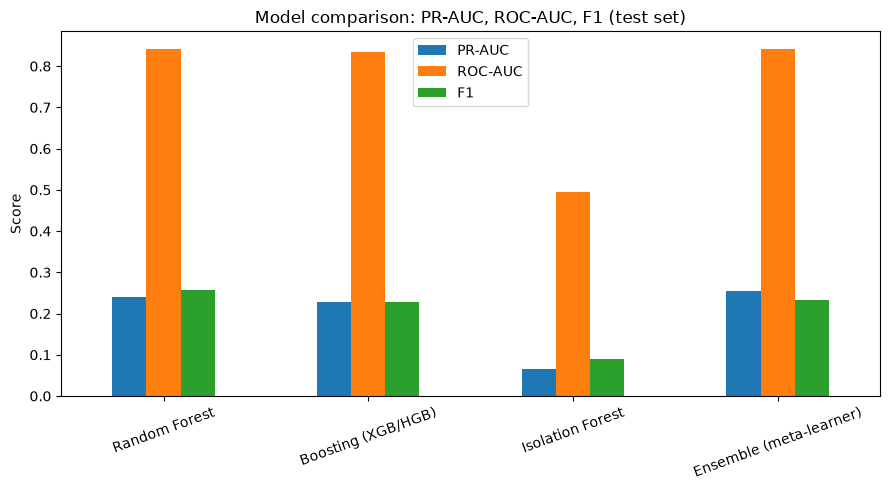

In [24]:
fig, ax = plt.subplots(figsize=(9,5))
comparison[['PR-AUC', 'ROC-AUC', 'F1']].plot(kind='bar', ax=ax)
ax.set_title('Model comparison: PR-AUC, ROC-AUC, F1 (test set)')
ax.set_ylabel('Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 8. Decision-fusion mechanism

The abstract calls for a mechanism that identifies **agreement**, **disagreement**, and cases
**requiring human review** — not just a single fraud/legit flag. We build this from two signals:

1. **Model agreement**: do Random Forest, Boosting, and Isolation Forest's individual flags
   (each thresholded at its own best operating point) all point the same way?
2. **Meta-learner confidence**: how far is the final probability from the decision boundary?

A claim only gets an automatic verdict when the base models agree *and* the meta-learner is
confident; everything else is routed to a human reviewer.

In [25]:
# Individual model flags at reasonable operating thresholds
rf_flag = (rf_test_proba >= 0.3).astype(int)
boost_flag = (boost_test_proba >= 0.3).astype(int)
if_flag = if_test_pred

votes = rf_flag + boost_flag + if_flag  # 0..3 models flagging this claim as fraud-like

CONF_LOW, CONF_HIGH = 0.35, 0.65  # meta-learner "gray zone" -> route to human review

def fuse(vote_count, meta_proba):
    if meta_proba >= CONF_HIGH and vote_count >= 2:
        return 'High-confidence Fraud'
    if meta_proba <= CONF_LOW and vote_count <= 1:
        return 'High-confidence Legit'
    return 'Disagreement - Human Review'

decisions = [fuse(v, p) for v, p in zip(votes, ensemble_test_proba)]

decision_counts = pd.Series(decisions).value_counts()
print("Decision-fusion outcome counts on the test set:")
print(decision_counts)
print("\n% requiring human review: {:.1f}%".format(
    100 * decision_counts.get('Disagreement - Human Review', 0) / len(decisions)))


Decision-fusion outcome counts on the test set:
High-confidence Legit          1708
High-confidence Fraud           743
Disagreement - Human Review     633
Name: count, dtype: int64

% requiring human review: 20.5%


### How good is each fusion bucket?

If the fusion logic is working well, the fraud rate inside "High-confidence Fraud" should be
much higher than the overall ~6% base rate, "High-confidence Legit" should be much lower, and
"Human Review" should sit somewhere in between (it's meant to catch the genuinely ambiguous
cases).

In [26]:
review_df = pd.DataFrame({'decision': decisions, 'true_label': y_test.values})
fraud_rate_by_bucket = review_df.groupby('decision')['true_label'].agg(['mean', 'count'])
fraud_rate_by_bucket.columns = ['fraud_rate', 'num_claims']
print(fraud_rate_by_bucket)


                             fraud_rate  num_claims
decision                                           
Disagreement - Human Review    0.078989         633
High-confidence Fraud          0.172275         743
High-confidence Legit          0.004098        1708


## 9. Per-claim results table

For every test claim: all three base-model outputs, the meta-learner's final probability, its
final prediction, the decision-fusion category, and the true label — exactly what you asked to
see per result.

In [27]:
final_results = pd.DataFrame({
    'claim_index': X_test_final.index,
    'rf_proba': rf_test_proba.round(4),
    'boosting_proba': boost_test_proba.round(4),
    'isolation_forest_anomaly_score': if_test_norm.round(4),
    'meta_learner_proba': ensemble_test_proba.round(4),
    'meta_learner_pred': ensemble_test_pred,
    'decision_fusion': decisions,
    'true_label': y_test.values,
})

final_results.to_csv("ensemble_final_results.csv", index=False)
print("Saved ensemble_final_results.csv —", final_results.shape[0], "rows")
final_results.head(15)


Saved ensemble_final_results.csv — 3084 rows


,claim_index,rf_proba,boosting_proba,isolation_forest_anomaly_score,meta_learner_proba,meta_learner_pred,decision_fusion,true_label
0,8922,0.0103,0.0643,0.1854,0.0725,0,High-confidence Legit,0
1,4274,0.2285,0.5098,0.2930,0.4772,0,Disagreement - Human Review,0
2,3408,0.0798,0.0171,0.6810,0.0705,0,High-confidence Legit,0
3,10675,0.2203,0.6257,0.1205,0.6001,1,Disagreement - Human Review,0
4,3285,0.0308,0.1726,0.2186,0.1183,0,High-confidence Legit,0
5,11043,0.3769,0.7239,0.2244,0.7599,1,High-confidence Fraud,0
6,3495,0.0182,0.0129,0.2800,0.0596,0,High-confidence Legit,0
7,9299,0.4773,0.7333,0.1602,0.7969,1,High-confidence Fraud,1
8,10652,0.0330,0.0117,0.1838,0.0600,0,High-confidence Legit,0
9,13126,0.0152,0.0102,0.2513,0.0584,0,High-confidence Legit,0


## 10. Save all artifacts

In [28]:
import joblib

joblib.dump(best_rf, "ensemble_rf_model.pkl")
joblib.dump(best_boost, "ensemble_boosting_model.pkl")
joblib.dump(iso_final, "ensemble_isolation_forest_model.pkl")
joblib.dump(meta_learner, "ensemble_meta_learner.pkl")

print("Saved 4 model artifacts:")
print(" - ensemble_rf_model.pkl")
print(" - ensemble_boosting_model.pkl")
print(" - ensemble_isolation_forest_model.pkl")
print(" - ensemble_meta_learner.pkl (Logistic Regression, inputs = [rf_proba, boost_proba, if_score])")


Saved 4 model artifacts:
 - ensemble_rf_model.pkl
 - ensemble_boosting_model.pkl
 - ensemble_isolation_forest_model.pkl
 - ensemble_meta_learner.pkl (Logistic Regression, inputs = [rf_proba, boost_proba, if_score])


## Summary

| Model | PR-AUC | ROC-AUC | Notes |
|---|---|---|---|
| Random Forest | see §7 table | see §7 table | Supervised, `class_weight='balanced'` |
| Boosting (XGBoost/HGB) | see §7 table | see §7 table | Supervised, `scale_pos_weight`/`class_weight` |
| Isolation Forest | see §7 table | see §7 table | Unsupervised — near chance-level here, expected |
| **Ensemble (meta-learner)** | see §7 table | see §7 table | Stacks all three; usually matches/edges out the best single model while adding the human-review safety net |

The next step in the full project (not part of this notebook) is to add the **LLM-based
reasoning** branch and fuse its independent fraud assessment with `ensemble_test_proba` here,
using the same agreement/disagreement logic built in §8.